# Asistente para estadística STATBOT

In [ ]:
!pip install scikit-learn scipy langgraph pillow pandas

import numpy as np
from typing import List, Dict, Any, TypedDict
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import ttest_1samp, chisquare

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

import pandas as pd
from PIL import Image
import io


## Base estadística

In [ ]:
textos_stats = [
"""
La estadística descriptiva se encarga de recolectar, organizar, resumir y presentar los datos.
Las medidas más importantes son la media, la varianza y la desviación estándar.
""",
"""
El valor p es la probabilidad de observar resultados tan extremos como los observados asumiendo verdadera la hipótesis nula.
Si p es menor que alfa se rechaza la hipótesis nula.
""",
"""
Las pruebas paramétricas suponen una distribución específica para los datos, por ejemplo normalidad.
Las pruebas no paramétricas no requieren este supuesto y se basan en rangos u órdenes.
""",
"""
En regresión lineal se modela la relación entre una variable respuesta y una o varias variables explicativas
mediante una ecuación lineal. El coeficiente de determinación R cuadrado mide la proporción de variabilidad explicada.
""",
"""
La prueba chi-cuadrado permite evaluar independencia entre variables categóricas usando tablas de contingencia.
"""
]


ampliado

In [ ]:
textos_stats_extra = [
"""
Una variable aleatoria es discreta si toma valores numerables y continua si puede tomar cualquier valor en un intervalo.
""",
"""
Un intervalo de confianza para la media poblacional es un rango de valores que, con cierto nivel de confianza, contiene al parámetro.
""",
"""
R cuadrado cercano a 1 indica que el modelo de regresión explica bien la variabilidad de la respuesta.
""",
"""
Las pruebas no paramétricas como Wilcoxon, Mann-Whitney o Kruskal-Wallis se utilizan cuando no se cumplen supuestos de normalidad
o cuando los datos están en escala ordinal.
"""
]

corpus_docs = [t.strip() for t in textos_stats + textos_stats_extra]
len(corpus_docs)


9

## RAG

In [ ]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus_docs)

def retrieve_context(question: str, k: int = 3) -> List[str]:
    q_vec = vectorizer.transform([question])
    sims = cosine_similarity(q_vec, tfidf_matrix)[0]
    idx = np.argsort(sims)[::-1][:k]
    return [corpus_docs[i] for i in idx]

def build_context_text(question: str, k: int = 3) -> str:
    ctx_list = retrieve_context(question, k=k)
    return "\n".join("- " + c for c in ctx_list)


## Tools cálculo estadístico

In [ ]:
def media(datos: List[float]) -> float:
    arr = np.array(datos, dtype=float)
    return float(arr.mean())

def varianza_muestral(datos: List[float]) -> float:
    arr = np.array(datos, dtype=float)
    return float(arr.var(ddof=1))

def resumen_descriptivo(datos: List[float]) -> Dict[str, Any]:
    arr = np.array(datos, dtype=float)
    media_val = float(arr.mean())
    sd = float(arr.std(ddof=1))
    return {
        "n": int(arr.size),
        "media": media_val,
        "mediana": float(np.median(arr)),
        "min": float(arr.min()),
        "max": float(arr.max()),
        "rango": float(arr.max() - arr.min()),
        "varianza_muestral": float(arr.var(ddof=1)),
        "desviacion_estandar_muestral": sd,
        "coeficiente_variacion": float(sd / media_val) if media_val != 0 else None
    }

def t_test_una_muestra(datos: List[float], mu0: float) -> Dict[str, Any]:
    arr = np.array(datos, dtype=float)
    t_stat, p_val = ttest_1samp(arr, mu0)
    return {
        "n": int(arr.size),
        "media_muestral": float(arr.mean()),
        "hipotesis_media": float(mu0),
        "t_stat": float(t_stat),
        "p_valor": float(p_val)
    }

def chi_cuadrado_bondad(observados: List[float], esperados: List[float]) -> Dict[str, Any]:
    obs = np.array(observados, dtype=float)
    exp = np.array(esperados, dtype=float)
    stat, p_val = chisquare(obs, f_exp=exp)
    return {
        "k": int(obs.size),
        "chi2": float(stat),
        "p_valor": float(p_val)
    }


## extraer datos de las preguntas

In [ ]:
def extraer_lista_numeros(texto: str) -> List[float]:
    numeros = re.findall(r"-?\d+\.?\d*", texto)
    return [float(x) for x in numeros]

def extraer_datos_y_mu0(texto: str):
    numeros = extraer_lista_numeros(texto)
    if len(numeros) < 2:
        return None, None
    datos = numeros[:-1]
    mu0 = numeros[-1]
    return datos, mu0

def extraer_listas_corchetes(texto: str) -> List[List[float]]:
    bloques = re.findall(r"\[([^\]]*)\]", texto)
    listas = []
    for b in bloques:
        nums = re.findall(r"-?\d+\.?\d*", b)
        if nums:
            listas.append([float(x) for x in nums])
    return listas


## Asistente

In [ ]:
def answer_stats(question: str) -> str:
    question_lower = question.lower()
    context_text = build_context_text(question, k=3)
    texto_respuesta = []

    if "[" in question and "]" in question:
        if "chi" in question_lower:
            listas = extraer_listas_corchetes(question)
            if len(listas) >= 2:
                observados = listas[0]
                esperados = listas[1]
                res_chi = chi_cuadrado_bondad(observados, esperados)
                texto_respuesta.append("Resultado de la prueba chi-cuadrado de bondad de ajuste:")
                texto_respuesta.append(str(res_chi))
        else:
            datos = extraer_lista_numeros(question)
            if len(datos) >= 2:
                if "prueba t" in question_lower or "t de una muestra" in question_lower:
                    datos_t, mu0 = extraer_datos_y_mu0(question)
                    if datos_t is not None:
                        res_t = t_test_una_muestra(datos_t, mu0)
                        texto_respuesta.append("Resultado de la prueba t de una muestra:")
                        texto_respuesta.append(str(res_t))
                else:
                    res_resumen = resumen_descriptivo(datos)
                    texto_respuesta.append("Resumen descriptivo de los datos:")
                    texto_respuesta.append(str(res_resumen))

    texto_respuesta.append("Contexto teórico relevante:")
    texto_respuesta.append(context_text)

    return "\n".join(texto_respuesta)


## Pruebas

In [ ]:
print("----- Pregunta 1 -----")
print(answer_stats("Explícame qué es el valor p."))

print("\n----- Pregunta 2 -----")
print(answer_stats("Cuál es la diferencia entre una prueba paramétrica y una no paramétrica?"))

print("\n----- Pregunta 3 -----")
print(answer_stats("Tengo los datos [10, 12, 9, 11, 13, 8]. Calcula la media y la varianza muestral."))

print("\n----- Pregunta 4 -----")
print(answer_stats("Con los datos [10, 12, 9, 11, 13, 8, 10], realiza una prueba t de una muestra contra media 10."))

print("\n----- Pregunta 5 -----")
print(answer_stats("Tengo frecuencias observadas [12, 15, 8] y frecuencias esperadas [10, 10, 15]. Realiza una prueba chi cuadrado de bondad de ajuste."))


----- Pregunta 1 -----
Contexto teórico relevante:
- El valor p es la probabilidad de observar resultados tan extremos como los observados asumiendo verdadera la hipótesis nula.
Si p es menor que alfa se rechaza la hipótesis nula.
- Una variable aleatoria es discreta si toma valores numerables y continua si puede tomar cualquier valor en un intervalo.
- R cuadrado cercano a 1 indica que el modelo de regresión explica bien la variabilidad de la respuesta.

----- Pregunta 2 -----
Contexto teórico relevante:
- En regresión lineal se modela la relación entre una variable respuesta y una o varias variables explicativas
mediante una ecuación lineal. El coeficiente de determinación R cuadrado mide la proporción de variabilidad explicada.
- La prueba chi-cuadrado permite evaluar independencia entre variables categóricas usando tablas de contingencia.
- Las pruebas paramétricas suponen una distribución específica para los datos, por ejemplo normalidad.
Las pruebas no paramétricas no requieren e

## LangGraph

In [ ]:
!pip install langgraph

from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver


In [ ]:
class StatsState(TypedDict):
    question: str
    context: str
    answer: str


## nodo RAG

In [ ]:
def rag_node(state: StatsState) -> StatsState:
    q = state["question"]
    ctx = build_context_text(q, k=3)
    return {"question": q, "context": ctx, "answer": ""}


## Nodo tools

In [ ]:
def answer_node(state: StatsState) -> StatsState:
    q = state["question"]
    ctx = state["context"]
    q_lower = q.lower()
    respuesta_parcial = []

    if "[" in q and "]" in q:
        if "chi" in q_lower:
            listas = extraer_listas_corchetes(q)
            if len(listas) >= 2:
                observados = listas[0]
                esperados = listas[1]
                res_chi = chi_cuadrado_bondad(observados, esperados)
                respuesta_parcial.append("Resultado de la prueba chi-cuadrado de bondad de ajuste:")
                respuesta_parcial.append(str(res_chi))
        else:
            datos = extraer_lista_numeros(q)
            if len(datos) >= 2:
                if "prueba t" in q_lower or "t de una muestra" in q_lower:
                    datos_t, mu0 = extraer_datos_y_mu0(q)
                    if datos_t is not None:
                        res_t = t_test_una_muestra(datos_t, mu0)
                        respuesta_parcial.append("Resultado de la prueba t de una muestra:")
                        respuesta_parcial.append(str(res_t))
                else:
                    res_resumen = resumen_descriptivo(datos)
                    respuesta_parcial.append("Resumen descriptivo de los datos:")
                    respuesta_parcial.append(str(res_resumen))

    respuesta_parcial.append("Contexto teórico relevante:")
    respuesta_parcial.append(ctx)

    return {
        "question": q,
        "context": ctx,
        "answer": "\n".join(respuesta_parcial)
    }


## Grafo

In [ ]:
builder = StateGraph(StatsState)
builder.add_node("RAG", rag_node)
builder.add_node("ANSWER", answer_node)

builder.add_edge(START, "RAG")
builder.add_edge("RAG", "ANSWER")
builder.add_edge("ANSWER", END)

memory = MemorySaver()
graph_stats = builder.compile(checkpointer=memory)


In [ ]:
def answer_stats_langgraph(question: str) -> str:
    state = {
        "question": question,
        "context": "",
        "answer": ""
    }
    config = {"configurable": {"thread_id": "stats-demo"}}
    result = graph_stats.invoke(state, config)
    return result["answer"]


## Pruebas

In [ ]:
print("----- LG Pregunta 1 -----")
print(answer_stats_langgraph("Explícame qué es el valor p."))

print("\n----- LG Pregunta 2 -----")
print(answer_stats_langgraph("Cuál es la diferencia entre una prueba paramétrica y una no paramétrica?"))

print("\n----- LG Pregunta 3 -----")
print(answer_stats_langgraph("Tengo los datos [10, 12, 9, 11, 13, 8]. Calcula la media y la varianza muestral."))

print("\n----- LG Pregunta 4 -----")
print(answer_stats_langgraph("Con los datos [10, 12, 9, 11, 13, 8, 10], realiza una prueba t de una muestra contra media 10."))

print("\n----- LG Pregunta 5 -----")
print(answer_stats_langgraph("Tengo frecuencias observadas [12, 15, 8] y frecuencias esperadas [10, 10, 15]. Realiza una prueba chi cuadrado de bondad de ajuste."))


----- LG Pregunta 1 -----
Contexto teórico relevante:
- El valor p es la probabilidad de observar resultados tan extremos como los observados asumiendo verdadera la hipótesis nula.
Si p es menor que alfa se rechaza la hipótesis nula.
- Una variable aleatoria es discreta si toma valores numerables y continua si puede tomar cualquier valor en un intervalo.
- R cuadrado cercano a 1 indica que el modelo de regresión explica bien la variabilidad de la respuesta.

----- LG Pregunta 2 -----
Contexto teórico relevante:
- En regresión lineal se modela la relación entre una variable respuesta y una o varias variables explicativas
mediante una ecuación lineal. El coeficiente de determinación R cuadrado mide la proporción de variabilidad explicada.
- La prueba chi-cuadrado permite evaluar independencia entre variables categóricas usando tablas de contingencia.
- Las pruebas paramétricas suponen una distribución específica para los datos, por ejemplo normalidad.
Las pruebas no paramétricas no requi

## Visualización Grafo

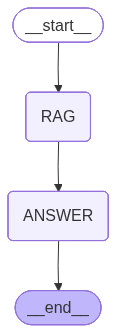

In [ ]:
png_bytes = graph_stats.get_graph().draw_mermaid_png()
Image.open(io.BytesIO(png_bytes))


## Pruebas con varias preguntas

In [ ]:
preguntas_prueba = [
    "Explícame qué es el valor p.",
    "Cuál es la diferencia entre prueba paramétrica y no paramétrica?",
    "Qué es una variable aleatoria continua?",
    "Qué significa R cuadrado en regresión lineal?",
    "Tengo los datos [10, 12, 9, 11, 13, 8]. Calcula la varianza muestral.",
    "Con los datos [10, 12, 9, 11, 13, 8, 10], realiza una prueba t de una muestra contra media 10.",
    "Tengo frecuencias observadas [12, 15, 8] y frecuencias esperadas [10, 10, 15]. Realiza una prueba chi cuadrado de bondad de ajuste."
]

respuestas = []
for q in preguntas_prueba:
    r = answer_stats_langgraph(q)
    respuestas.append({"pregunta": q, "respuesta": r})

df_resultados = pd.DataFrame(respuestas)
df_resultados


,pregunta,respuesta
0,Explícame qué es el valor p.,Contexto teórico relevante:\n- El valor p es l...
1,Cuál es la diferencia entre prueba paramétrica...,Contexto teórico relevante:\n- La prueba chi-c...
2,Qué es una variable aleatoria continua?,Contexto teórico relevante:\n- Una variable al...
3,Qué significa R cuadrado en regresión lineal?,Contexto teórico relevante:\n- En regresión li...
4,"Tengo los datos [10, 12, 9, 11, 13, 8]. Calcul...","Resumen descriptivo de los datos:\n{'n': 6, 'm..."
5,"Con los datos [10, 12, 9, 11, 13, 8, 10], real...",Resultado de la prueba t de una muestra:\n{'n'...
6,"Tengo frecuencias observadas [12, 15, 8] y fre...",Resultado de la prueba chi-cuadrado de bondad ...
